# Терентьев И.В. М8О-214СВ-24

Лабораторная работа №1 
«Анализ и прогнозирование временных рядов на примере розничных продаж»

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from scipy import stats
import statsmodels.api as sm
from scipy.fft import fft, fftfreq
from scipy import signal
import pywt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('retail_sales_mock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [3]:
print("Первые 5 строк данных:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОсновные статистические характеристики:")
print(df.describe())

Первые 5 строк данных:
            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-01-01        12248          0             0
2020-02-01        13011          0             0
2020-03-01        12722          0             0
2020-04-01        14030          1             0
2020-05-01         7783          0             0

Информация о данных:
<class 'pandas.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB
None

Основные статистические характеристики:
        SalesAmount  Promotion  HolidayMonth
count     48.000000  48.000000     48.000000
mean   11768.541667   0.125000      0.083333
std     2257.544863   0.334219      0.279310
min     7783.000000   0.000000  

In [4]:
# Добавляем вспомогательные колонки
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Quarter'] = df.index.quarter
df['MonthName'] = df.index.strftime('%b')

# 2. Разведочный анализ данных (EDA)

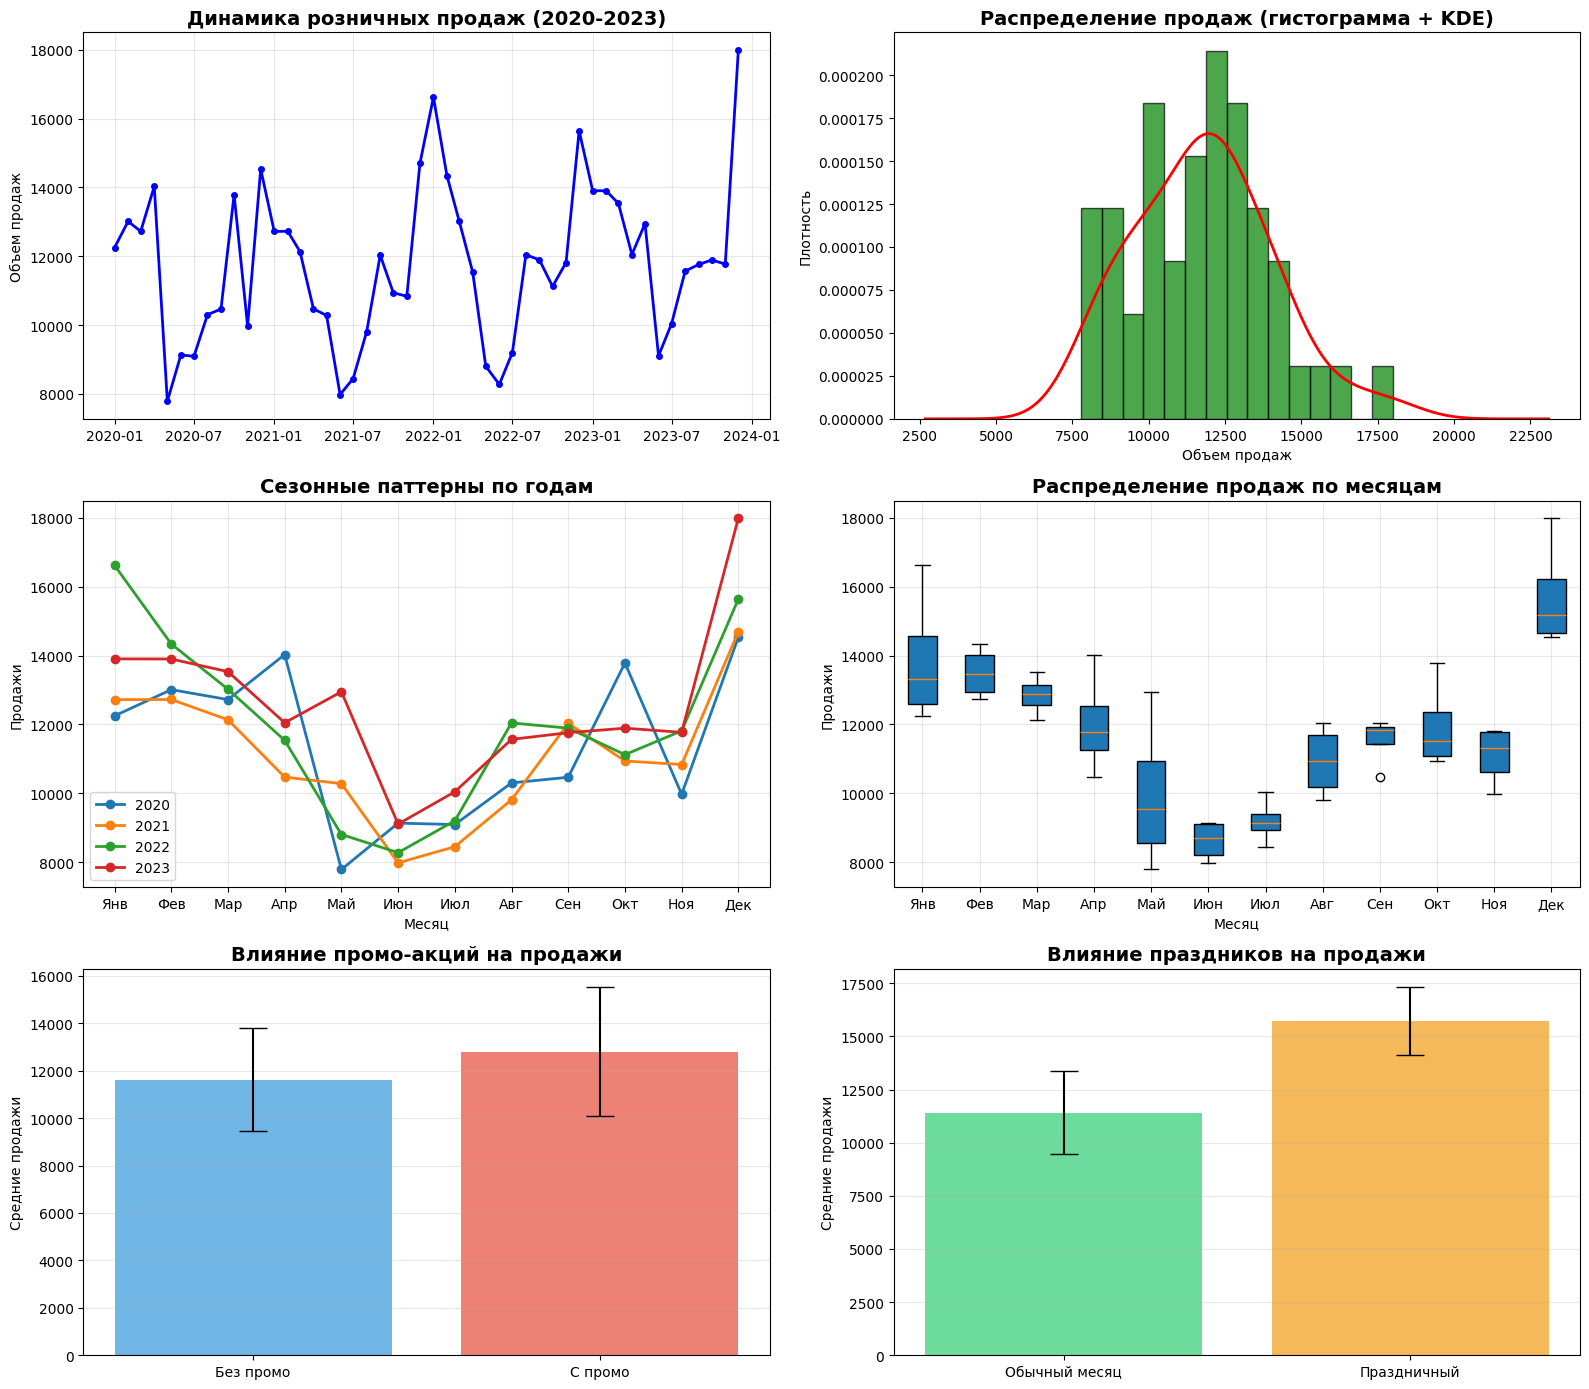

In [5]:
# Визуализация временного ряда
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Исходный ряд
axes[0, 0].plot(df.index, df['SalesAmount'], linewidth=2, color='blue', marker='o', markersize=4)
axes[0, 0].set_title('Динамика розничных продаж (2020-2023)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Объем продаж')
axes[0, 0].grid(True, alpha=0.3)

# Распределение продаж
axes[0, 1].hist(df['SalesAmount'], bins=15, edgecolor='black', alpha=0.7, color='green', density=True)
df['SalesAmount'].plot(kind='kde', ax=axes[0, 1], color='red', linewidth=2, secondary_y=False)
axes[0, 1].set_title('Распределение продаж (гистограмма + KDE)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Объем продаж')
axes[0, 1].set_ylabel('Плотность')

# Продажи по годам
for year in sorted(df['Year'].unique()):
    year_data = df[df['Year'] == year]
    axes[1, 0].plot(year_data.index.month, year_data['SalesAmount'], 
                    marker='o', linewidth=2, label=year)
axes[1, 0].set_title('Сезонные паттерны по годам', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Продажи')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                            'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])

# Boxplot по месяцам
monthly_data = [df[df['Month'] == m]['SalesAmount'].values for m in range(1, 13)]
bp = axes[1, 1].boxplot(monthly_data, positions=range(1, 13), patch_artist=True)
axes[1, 1].set_title('Распределение продаж по месяцам', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Продажи')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                            'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
axes[1, 1].grid(True, alpha=0.3)

# Влияние промо-акций
promo_stats = df.groupby('Promotion')['SalesAmount'].agg(['mean', 'std', 'count'])
promo_stats.index = ['Без промо', 'С промо']
axes[2, 0].bar(promo_stats.index, promo_stats['mean'], 
               yerr=promo_stats['std'], capsize=10, 
               color=['#3498db', '#e74c3c'], alpha=0.7)
axes[2, 0].set_title('Влияние промо-акций на продажи', fontsize=14, fontweight='bold')
axes[2, 0].set_ylabel('Средние продажи')
axes[2, 0].grid(True, alpha=0.3, axis='y')

# Влияние праздников
holiday_stats = df.groupby('HolidayMonth')['SalesAmount'].agg(['mean', 'std', 'count'])
holiday_stats.index = ['Обычный месяц', 'Праздничный']
axes[2, 1].bar(holiday_stats.index, holiday_stats['mean'],
               yerr=holiday_stats['std'], capsize=10,
               color=['#2ecc71', '#f39c12'], alpha=0.7)
axes[2, 1].set_title('Влияние праздников на продажи', fontsize=14, fontweight='bold')
axes[2, 1].set_ylabel('Средние продажи')
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [6]:
print("Статистический анализ влияния факторов:")
print("-" * 50)

# Влияние промо
promo_test = stats.ttest_ind(df[df['Promotion']==1]['SalesAmount'],
                            df[df['Promotion']==0]['SalesAmount'])
print(f"\nВлияние промо-акций:")
print(f"  Без промо: среднее={promo_stats.loc['Без промо', 'mean']:.0f}, n={promo_stats.loc['Без промо', 'count']:.0f}")
print(f"  С промо: среднее={promo_stats.loc['С промо', 'mean']:.0f}, n={promo_stats.loc['С промо', 'count']:.0f}")
print(f"  Рост: {((promo_stats.loc['С промо', 'mean']/promo_stats.loc['Без промо', 'mean'])-1)*100:.1f}%")
print(f"  T-тест: p-value={promo_test.pvalue:.4f}")

# Влияние праздников
holiday_test = stats.ttest_ind(df[df['HolidayMonth']==1]['SalesAmount'],
                              df[df['HolidayMonth']==0]['SalesAmount'])
print(f"\nВлияние праздников:")
print(f"  Обычный месяц: среднее={holiday_stats.loc['Обычный месяц', 'mean']:.0f}, n={holiday_stats.loc['Обычный месяц', 'count']:.0f}")
print(f"  Праздничный: среднее={holiday_stats.loc['Праздничный', 'mean']:.0f}, n={holiday_stats.loc['Праздничный', 'count']:.0f}")
print(f"  Рост: {((holiday_stats.loc['Праздничный', 'mean']/holiday_stats.loc['Обычный месяц', 'mean'])-1)*100:.1f}%")
print(f"  T-тест: p-value={holiday_test.pvalue:.4f}")

Статистический анализ влияния факторов:
--------------------------------------------------

Влияние промо-акций:
  Без промо: среднее=11621, n=42
  С промо: среднее=12800, n=6
  Рост: 10.1%
  T-тест: p-value=0.2356

Влияние праздников:
  Обычный месяц: среднее=11410, n=44
  Праздничный: среднее=15718, n=4
  Рост: 37.8%
  T-тест: p-value=0.0001


In [7]:
# Проверка стационарности
def test_stationarity(timeseries, title):
    result = adfuller(timeseries.dropna())
    print(f'\nРезультаты теста Дики-Фуллера для {title}:')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Критические значения:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    print(f'Ряд {"стационарен" if result[1] < 0.05 else "нестационарен"}')
    return result[1] < 0.05

is_stationary = test_stationarity(df['SalesAmount'], 'исходного ряда')


Результаты теста Дики-Фуллера для исходного ряда:
ADF Statistic: -4.514184
p-value: 0.000185
Критические значения:
	1%: -3.597
	5%: -2.933
	10%: -2.605
Ряд стационарен


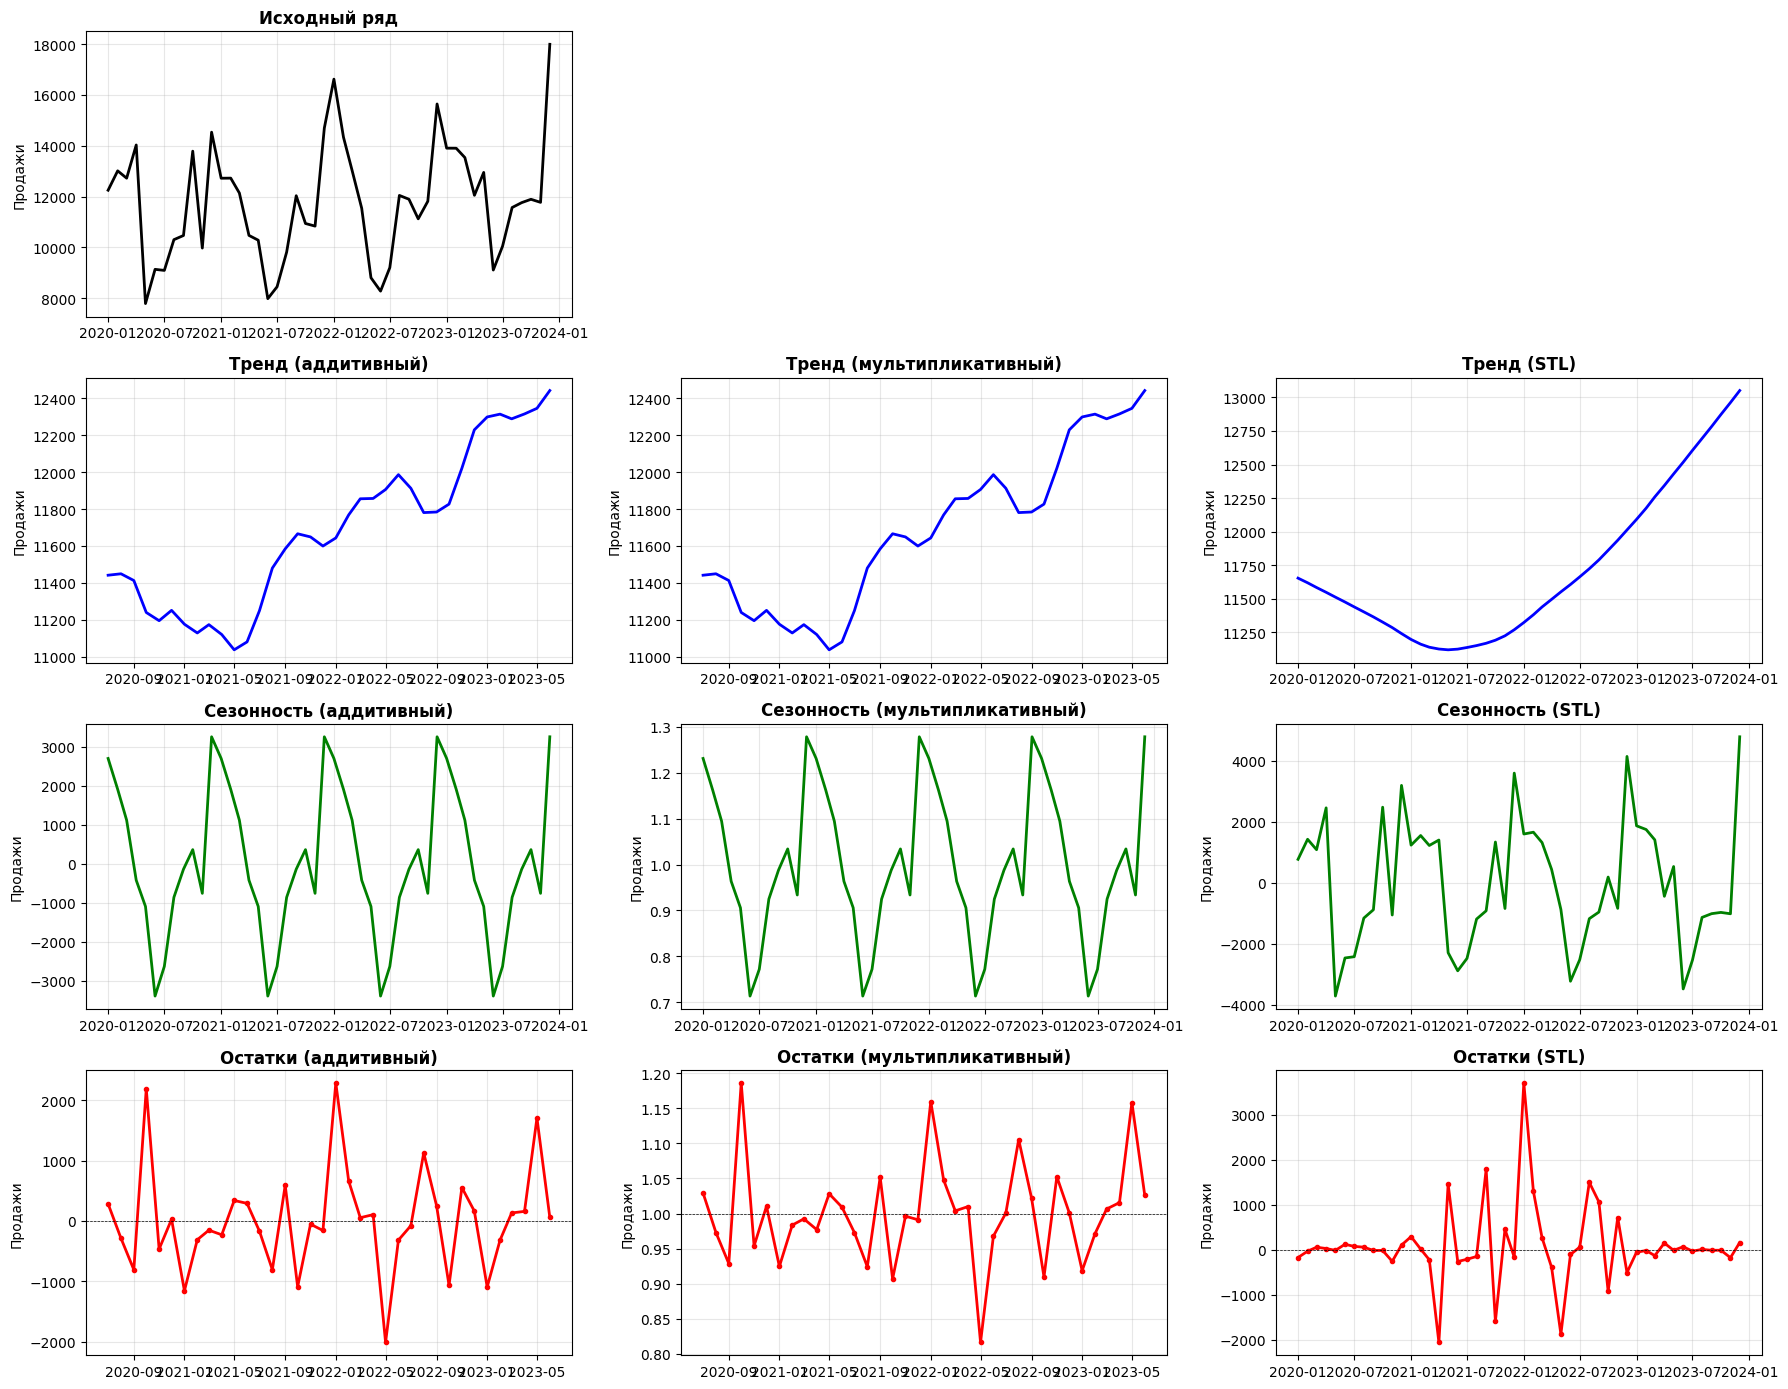


Сравнение дисперсии остатков:
            Метод  Дисперсия остатков
       Аддитивная       759380.254431
Мультипликативная            0.005367
              STL       779107.885831


In [8]:
# Аддитивная декомпозиция
decomposition_add = seasonal_decompose(df['SalesAmount'], model='additive', period=12)

# Мультипликативная декомпозиция
decomposition_mult = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)

# STL декомпозиция (более устойчивая к выбросам)
stl = STL(df['SalesAmount'], period=12, robust=True)
result_stl = stl.fit()

# Визуализация
fig, axes = plt.subplots(4, 3, figsize=(18, 14))

# Оригинальный ряд
axes[0, 0].plot(df.index, df['SalesAmount'], color='black', linewidth=2)
axes[0, 0].set_title('Исходный ряд', fontweight='bold', fontsize=12)
axes[0, 1].axis('off')
axes[0, 2].axis('off')

# Аддитивная декомпозиция
axes[1, 0].plot(df.index, decomposition_add.trend, color='blue', linewidth=2)
axes[1, 0].set_title('Тренд (аддитивный)', fontweight='bold')
axes[2, 0].plot(df.index, decomposition_add.seasonal, color='green', linewidth=2)
axes[2, 0].set_title('Сезонность (аддитивный)', fontweight='bold')
axes[3, 0].plot(df.index, decomposition_add.resid, color='red', linewidth=2, marker='o', markersize=3)
axes[3, 0].set_title('Остатки (аддитивный)', fontweight='bold')
axes[3, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Мультипликативная декомпозиция
axes[1, 1].plot(df.index, decomposition_mult.trend, color='blue', linewidth=2)
axes[1, 1].set_title('Тренд (мультипликативный)', fontweight='bold')
axes[2, 1].plot(df.index, decomposition_mult.seasonal, color='green', linewidth=2)
axes[2, 1].set_title('Сезонность (мультипликативный)', fontweight='bold')
axes[3, 1].plot(df.index, decomposition_mult.resid, color='red', linewidth=2, marker='o', markersize=3)
axes[3, 1].set_title('Остатки (мультипликативный)', fontweight='bold')
axes[3, 1].axhline(y=1, color='black', linestyle='--', linewidth=0.5)

# STL декомпозиция
axes[1, 2].plot(df.index, result_stl.trend, color='blue', linewidth=2)
axes[1, 2].set_title('Тренд (STL)', fontweight='bold')
axes[2, 2].plot(df.index, result_stl.seasonal, color='green', linewidth=2)
axes[2, 2].set_title('Сезонность (STL)', fontweight='bold')
axes[3, 2].plot(df.index, result_stl.resid, color='red', linewidth=2, marker='o', markersize=3)
axes[3, 2].set_title('Остатки (STL)', fontweight='bold')
axes[3, 2].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)
    if ax != axes[0, 1] and ax != axes[0, 2]:
        ax.set_ylabel('Продажи')

plt.tight_layout()
plt.show()

# Сравнение дисперсии остатков
resid_var = pd.DataFrame({
    'Метод': ['Аддитивная', 'Мультипликативная', 'STL'],
    'Дисперсия остатков': [
        decomposition_add.resid.var(),
        decomposition_mult.resid.var(),
        result_stl.resid.var()
    ]
})
print("\nСравнение дисперсии остатков:")
print(resid_var.to_string(index=False))


In [9]:
# Спектральный анализ (FFT)
# Подготовка данных (центрируем для удаления постоянной составляющей)
sales_values = df['SalesAmount'].values
centered_values = sales_values - np.mean(sales_values)

# FFT анализ
n = len(sales_values)
sales_fft = fft(centered_values)
freq = fftfreq(n, d=1)
amplitude = np.abs(sales_fft[:n//2])
phases = np.angle(sales_fft[:n//2])
freq_positive = freq[:n//2]

# Поиск значимых частот (исключая нулевую)
non_zero_mask = freq_positive > 1e-10
freq_nonzero = freq_positive[non_zero_mask]
amp_nonzero = amplitude[non_zero_mask]

# Порог для значимых частот
threshold = np.max(amp_nonzero) * 0.3
significant_mask = amp_nonzero > threshold
significant_freqs = freq_nonzero[significant_mask]
significant_periods = 1 / significant_freqs
significant_amps = amp_nonzero[significant_mask]


Основные периоды сезонности:
 Период (мес)  Амплитуда
         12.0    57678.6
          4.0    20504.2


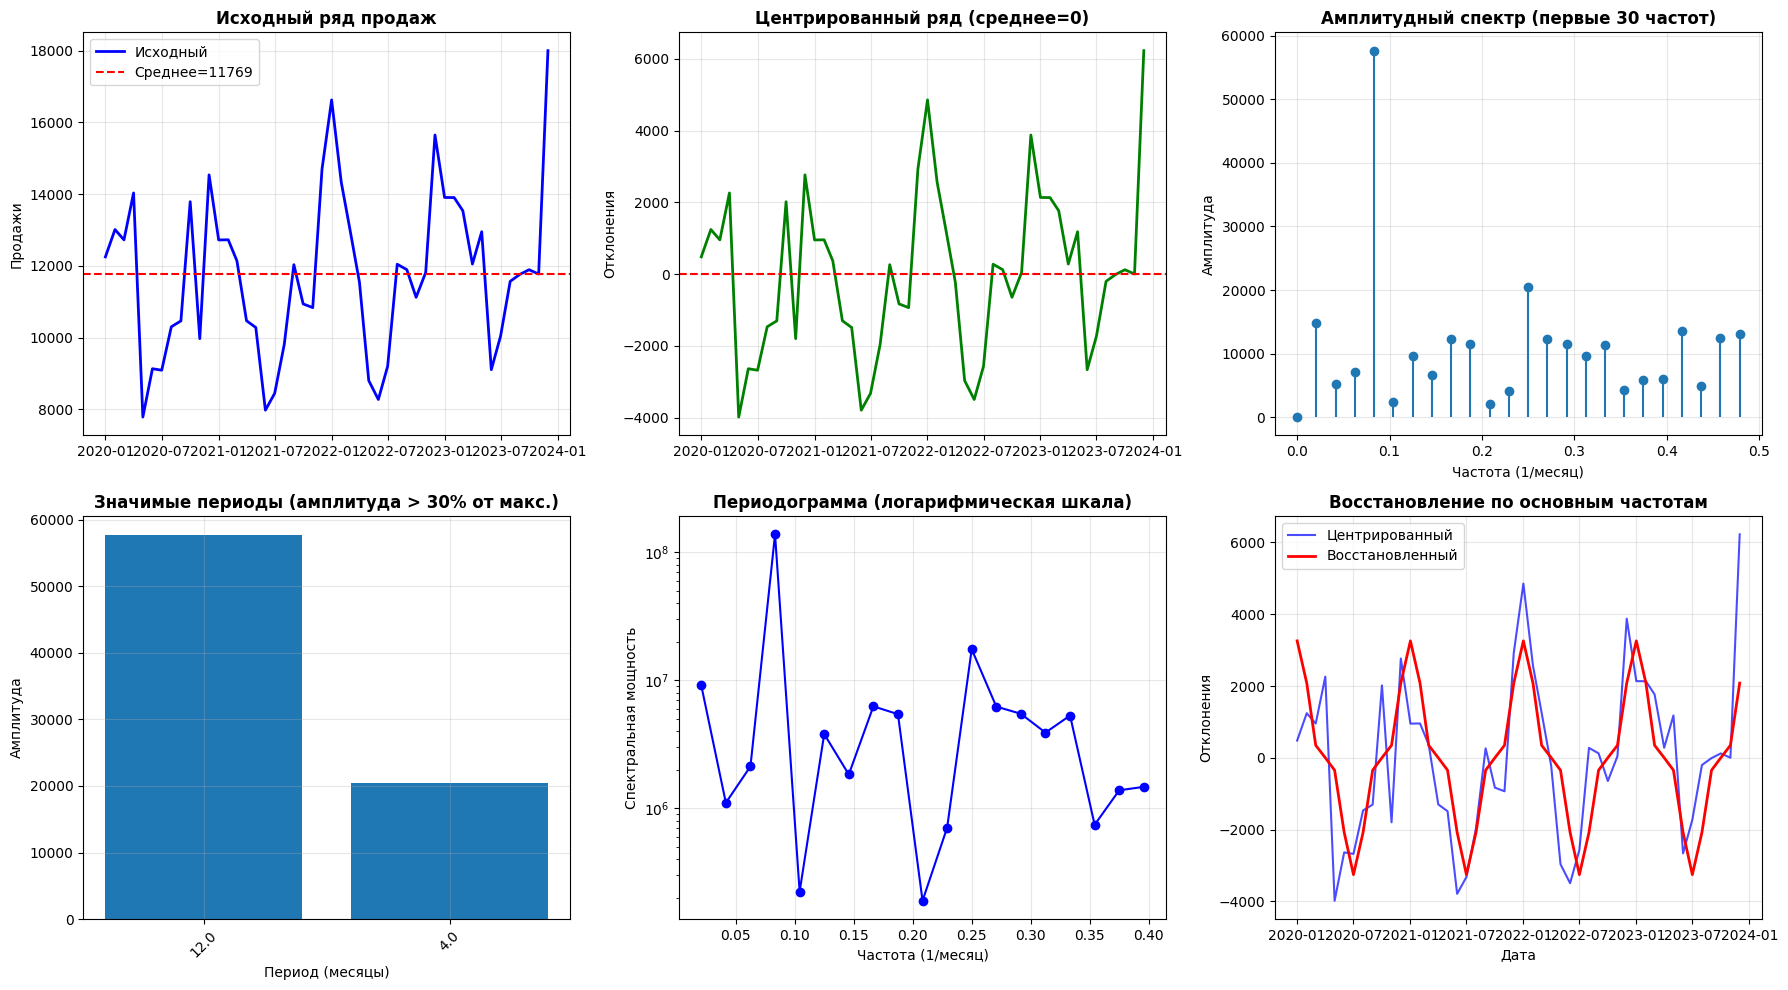

In [10]:
# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Исходный и центрированный ряды
axes[0, 0].plot(df.index, sales_values, 'b-', linewidth=2, label='Исходный')
axes[0, 0].axhline(y=np.mean(sales_values), color='r', linestyle='--', label=f'Среднее={np.mean(sales_values):.0f}')
axes[0, 0].set_title('Исходный ряд продаж', fontweight='bold')
axes[0, 0].set_ylabel('Продажи')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(df.index, centered_values, 'g-', linewidth=2)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_title('Центрированный ряд (среднее=0)', fontweight='bold')
axes[0, 1].set_ylabel('Отклонения')
axes[0, 1].grid(True, alpha=0.3)

# Амплитудный спектр
axes[0, 2].stem(freq_positive[:30], amplitude[:30], basefmt=" ")
axes[0, 2].set_title('Амплитудный спектр (первые 30 частот)', fontweight='bold')
axes[0, 2].set_xlabel('Частота (1/месяц)')
axes[0, 2].set_ylabel('Амплитуда')
axes[0, 2].grid(True, alpha=0.3)

# Значимые периоды
if len(significant_periods) > 0:
    periods_df = pd.DataFrame({
        'Период (мес)': significant_periods,
        'Частота': significant_freqs,
        'Амплитуда': significant_amps
    }).sort_values('Амплитуда', ascending=False)
    
    axes[1, 0].bar(range(len(periods_df)), periods_df['Амплитуда'])
    axes[1, 0].set_xticks(range(len(periods_df)))
    axes[1, 0].set_xticklabels([f'{p:.1f}' for p in periods_df['Период (мес)']], rotation=45)
    axes[1, 0].set_title('Значимые периоды (амплитуда > 30% от макс.)', fontweight='bold')
    axes[1, 0].set_xlabel('Период (месяцы)')
    axes[1, 0].set_ylabel('Амплитуда')
    axes[1, 0].grid(True, alpha=0.3)
    
    print("\nОсновные периоды сезонности:")
    print(periods_df[['Период (мес)', 'Амплитуда']].round(2).to_string(index=False))
else:
    axes[1, 0].text(0.5, 0.5, 'Нет значимых периодов', ha='center', va='center')

# Периодограмма
frequencies, power_spectrum = signal.periodogram(centered_values, fs=1)
axes[1, 1].semilogy(frequencies[1:20], power_spectrum[1:20], 'bo-')
axes[1, 1].set_title('Периодограмма (логарифмическая шкала)', fontweight='bold')
axes[1, 1].set_xlabel('Частота (1/месяц)')
axes[1, 1].set_ylabel('Спектральная мощность')
axes[1, 1].grid(True, alpha=0.3)

# Восстановление сигнала
reconstructed = np.zeros(n)
for idx, freq_val in enumerate(significant_freqs[:5]):
    reconstructed += 2*significant_amps[idx]/n * np.cos(2*np.pi*freq_val*np.arange(n))

axes[1, 2].plot(df.index, centered_values, 'b-', alpha=0.7, label='Центрированный')
axes[1, 2].plot(df.index, reconstructed, 'r-', linewidth=2, label='Восстановленный')
axes[1, 2].set_title('Восстановление по основным частотам', fontweight='bold')
axes[1, 2].set_xlabel('Дата')
axes[1, 2].set_ylabel('Отклонения')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

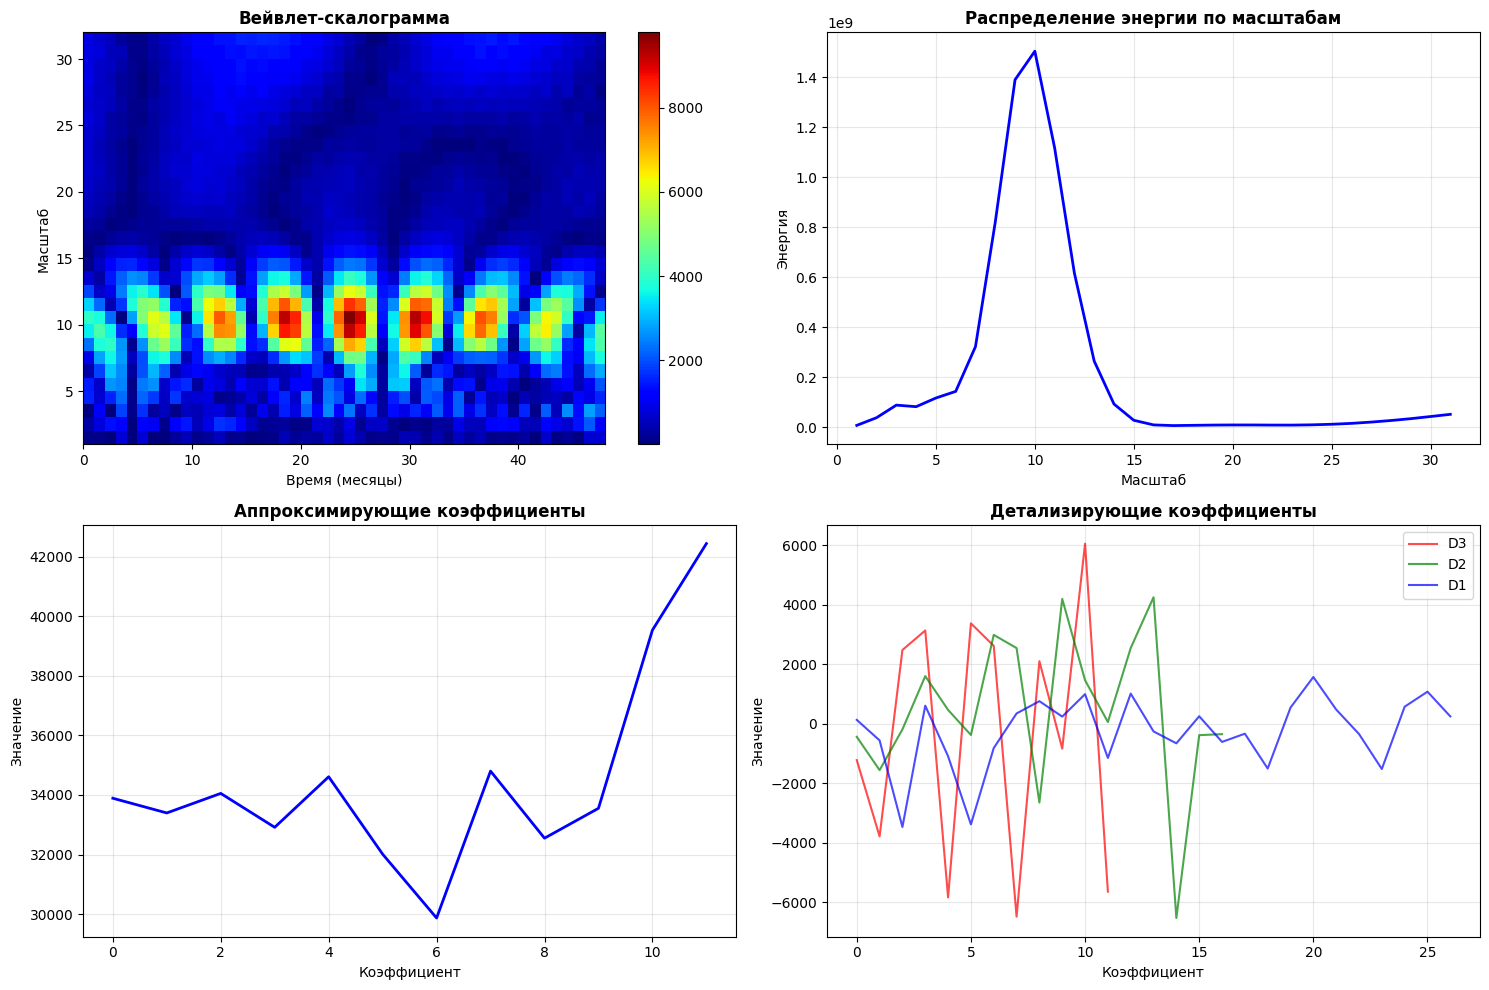

In [11]:
# Непрерывное вейвлет-преобразование
scales = np.arange(1, 32)
coefficients, frequencies = pywt.cwt(centered_values, scales, 'morl', sampling_period=1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Скалограмма
im = axes[0, 0].imshow(np.abs(coefficients), extent=[0, n, 1, 32], 
                        aspect='auto', cmap='jet', origin='lower')
axes[0, 0].set_title('Вейвлет-скалограмма', fontweight='bold')
axes[0, 0].set_xlabel('Время (месяцы)')
axes[0, 0].set_ylabel('Масштаб')
plt.colorbar(im, ax=axes[0, 0])

# Энергия по масштабам
energy = np.sum(np.abs(coefficients)**2, axis=1)
axes[0, 1].plot(scales, energy, 'b-', linewidth=2)
axes[0, 1].set_title('Распределение энергии по масштабам', fontweight='bold')
axes[0, 1].set_xlabel('Масштаб')
axes[0, 1].set_ylabel('Энергия')
axes[0, 1].grid(True, alpha=0.3)

# Дискретное вейвлет-преобразование
coeffs = pywt.wavedec(sales_values, 'db4', level=3)

# Визуализация коэффициентов
axes[1, 0].plot(coeffs[0], 'b-', linewidth=2)
axes[1, 0].set_title('Аппроксимирующие коэффициенты', fontweight='bold')
axes[1, 0].set_xlabel('Коэффициент')
axes[1, 0].set_ylabel('Значение')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(coeffs[1], 'r-', linewidth=1.5, alpha=0.7, label='D3')
axes[1, 1].plot(coeffs[2], 'g-', linewidth=1.5, alpha=0.7, label='D2')
axes[1, 1].plot(coeffs[3], 'b-', linewidth=1.5, alpha=0.7, label='D1')
axes[1, 1].set_title('Детализирующие коэффициенты', fontweight='bold')
axes[1, 1].set_xlabel('Коэффициент')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Прогнозные модели

Обучающая выборка: 2020-01 - 2023-02 (38 месяцев)
Тестовая выборка: 2023-03 - 2023-12 (10 месяцев)
Максимально допустимый лаг для PACF: 18
Используем количество лагов: 18


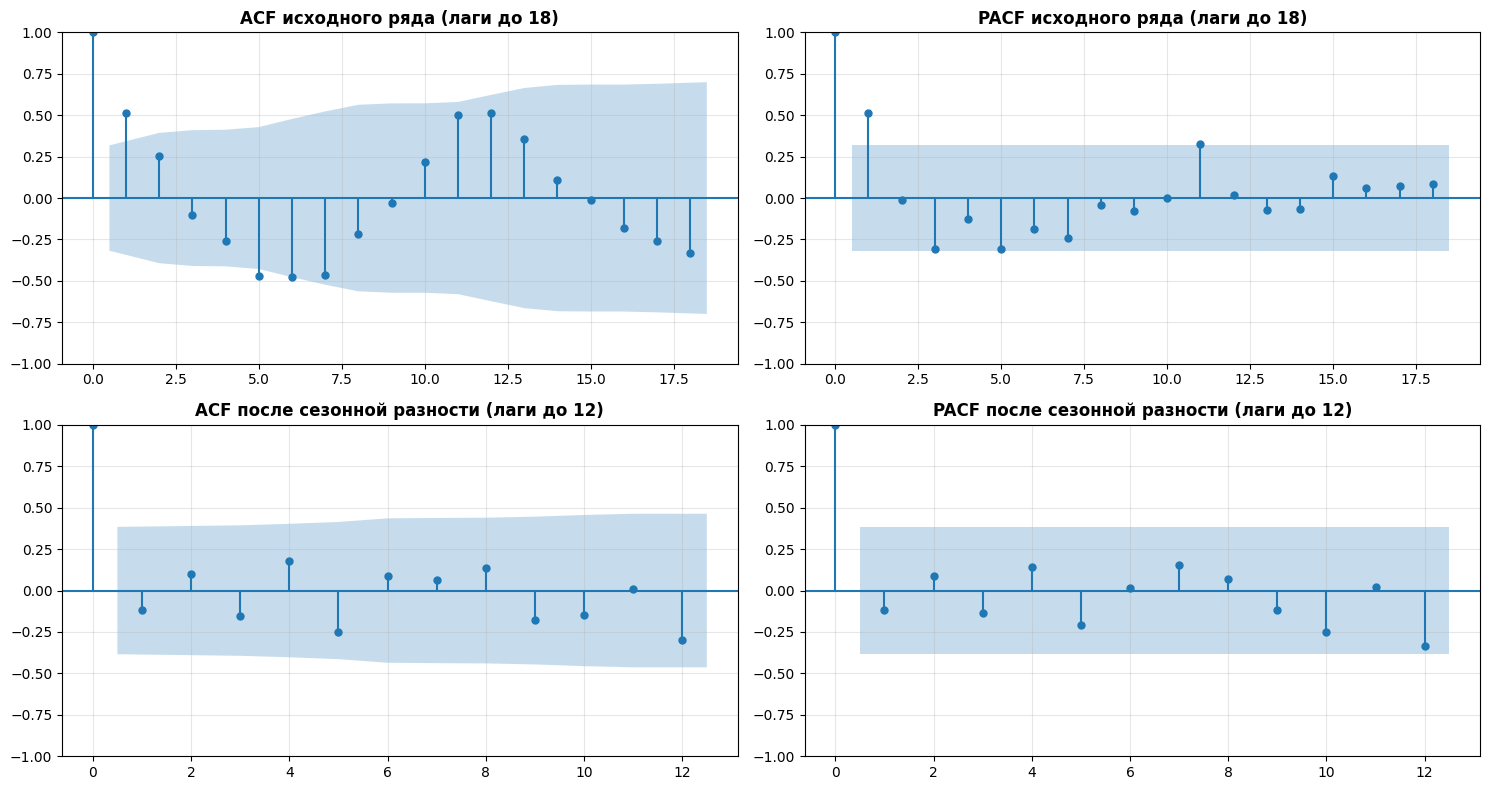

Подбор параметров ARIMA...
ARIMA(0, 0, 0): AIC=697.05
ARIMA(0, 0, 1): AIC=690.87
ARIMA(0, 0, 2): AIC=687.85
ARIMA(0, 0, 3): AIC=690.85
ARIMA(0, 1, 0): AIC=675.55
ARIMA(0, 1, 1): AIC=677.18
ARIMA(0, 1, 2): AIC=678.67
ARIMA(0, 1, 3): AIC=677.95
ARIMA(1, 0, 0): AIC=687.27
ARIMA(1, 0, 1): AIC=689.36
ARIMA(1, 0, 2): AIC=693.06
ARIMA(1, 0, 3): AIC=688.43
ARIMA(1, 1, 0): AIC=676.61
ARIMA(1, 1, 1): AIC=678.59
ARIMA(1, 1, 2): AIC=680.41
ARIMA(1, 1, 3): AIC=677.93
ARIMA(2, 0, 0): AIC=689.30
ARIMA(2, 0, 1): AIC=689.92
ARIMA(2, 0, 3): AIC=677.37
ARIMA(2, 1, 0): AIC=678.60
ARIMA(2, 1, 1): AIC=681.34
ARIMA(2, 1, 2): AIC=679.27
ARIMA(2, 1, 3): AIC=675.27
ARIMA(3, 0, 0): AIC=687.95
ARIMA(3, 1, 0): AIC=680.46
ARIMA(3, 1, 1): AIC=677.24

Топ-5 моделей по AIC:
    order        aic        bic
(2, 1, 3) 675.267228 684.932736
(0, 1, 0) 675.554789 677.165707
(1, 1, 0) 676.610027 679.831863
(0, 1, 1) 677.182841 680.404676
(3, 1, 1) 677.243547 685.298136

Лучшая модель ARIMA: (2, 1, 3)
AIC: 675.27

Подбор пара

In [12]:
# Разделение на обучающую и тестовую выборки
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Обучающая выборка: {train.index[0].strftime('%Y-%m')} - {train.index[-1].strftime('%Y-%m')} ({len(train)} месяцев)")
print(f"Тестовая выборка: {test.index[0].strftime('%Y-%m')} - {test.index[-1].strftime('%Y-%m')} ({len(test)} месяцев)")
print(f"Максимально допустимый лаг для PACF: {len(train)//2 - 1}")

# Анализ ACF и PACF с корректными лагами
max_lag = min(20, len(train)//2 - 1)  # Безопасное значение лага
print(f"Используем количество лагов: {max_lag}")

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# ACF и PACF для исходного ряда
plot_acf(train['SalesAmount'], lags=max_lag, ax=axes[0, 0])
axes[0, 0].set_title(f'ACF исходного ряда (лаги до {max_lag})', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

plot_pacf(train['SalesAmount'], lags=max_lag, ax=axes[0, 1])
axes[0, 1].set_title(f'PACF исходного ряда (лаги до {max_lag})', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Для сезонной разности
train_seasonal_diff = train['SalesAmount'].diff(12).dropna()
max_lag_diff = min(20, len(train_seasonal_diff)//2 - 1)

plot_acf(train_seasonal_diff, lags=max_lag_diff, ax=axes[1, 0])
axes[1, 0].set_title(f'ACF после сезонной разности (лаги до {max_lag_diff})', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

plot_pacf(train_seasonal_diff, lags=max_lag_diff, ax=axes[1, 1])
axes[1, 1].set_title(f'PACF после сезонной разности (лаги до {max_lag_diff})', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Функция для подбора параметров ARIMA с учетом ограничений
def find_best_arima(endog, max_p=3, max_d=1, max_q=3):
    """
    Подбор лучшей модели ARIMA с ограниченным количеством параметров
    из-за небольшого размера выборки
    """
    best_aic = np.inf
    best_order = None
    best_model = None
    results_list = []
    
    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                try:
                    # Проверяем, что сумма параметров не превышает разумный предел
                    if p + q > 6:  # Ограничиваем сложность модели
                        continue
                        
                    model = ARIMA(endog, order=(p, d, q))
                    results = model.fit()
                    
                    # Проверяем сходимость модели
                    if not results.mle_retvals['converged']:
                        continue
                        
                    aic = results.aic
                    results_list.append({
                        'order': (p, d, q),
                        'aic': aic,
                        'bic': results.bic
                    })
                    
                    if aic < best_aic:
                        best_aic = aic
                        best_order = (p, d, q)
                        best_model = results
                        
                    print(f"ARIMA{(p,d,q)}: AIC={aic:.2f}")
                except Exception as e:
                    continue
    
    # Сортируем результаты и выводим топ-5
    if results_list:
        results_df = pd.DataFrame(results_list)
        results_df = results_df.sort_values('aic').head(5)
        print("\nТоп-5 моделей по AIC:")
        print(results_df.to_string(index=False))
    
    return best_order, best_model, best_aic

print("Подбор параметров ARIMA...")
best_order, best_arima, best_aic = find_best_arima(train['SalesAmount'])
print(f"\nЛучшая модель ARIMA: {best_order}")
print(f"AIC: {best_aic:.2f}")

# Функция для подбора параметров SARIMAX с учетом ограничений
def find_best_sarimax(endog, max_p=2, max_d=1, max_q=2, 
                      max_P=1, max_D=1, max_Q=1, s=12):
    """
    Подбор лучшей модели SARIMAX с ограниченным количеством параметров
    из-за небольшого размера выборки
    """
    best_aic = np.inf
    best_order = None
    best_seasonal = None
    best_model = None
    results_list = []
    
    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                for P in range(max_P + 1):
                    for D in range(max_D + 1):
                        for Q in range(max_Q + 1):
                            try:
                                # Проверяем, что сумма параметров не превышает разумный предел
                                if p + q + P + Q > 8:
                                    continue
                                    
                                model = SARIMAX(endog,
                                               order=(p, d, q),
                                               seasonal_order=(P, D, Q, s),
                                               enforce_stationarity=False,
                                               enforce_invertibility=False)
                                results = model.fit(disp=False)
                                
                                # Проверяем сходимость
                                if not results.mle_retvals['converged']:
                                    continue
                                
                                aic = results.aic
                                results_list.append({
                                    'order': f"({p},{d},{q})x({P},{D},{Q},{s})",
                                    'aic': aic,
                                    'bic': results.bic
                                })
                                
                                if aic < best_aic:
                                    best_aic = aic
                                    best_order = (p, d, q)
                                    best_seasonal = (P, D, Q, s)
                                    best_model = results
                                
                                print(f"SARIMAX({p},{d},{q})x({P},{D},{Q},{s}): AIC={aic:.2f}")
                            except Exception as e:
                                continue
    
    # Сортируем результаты и выводим топ-5
    if results_list:
        results_df = pd.DataFrame(results_list)
        results_df = results_df.sort_values('aic').head(5)
        print("\nТоп-5 моделей по AIC:")
        print(results_df.to_string(index=False))
    
    return best_order, best_seasonal, best_model, best_aic

print("\nПодбор параметров SARIMAX...")
best_order_s, best_seasonal, best_sarimax, best_aic_s = find_best_sarimax(train['SalesAmount'])

if best_order_s:
    print(f"\nЛучшая модель SARIMAX: {best_order_s} x {best_seasonal}")
    print(f"AIC: {best_aic_s:.2f}")
else:
    print("Не удалось подобрать SARIMAX модель. Используем упрощенные параметры.")
    # Запасной вариант с простыми параметрами
    best_order_s = (1, 0, 1)
    best_seasonal = (1, 0, 1, 12)
    best_sarimax = SARIMAX(train['SalesAmount'],
                          order=best_order_s,
                          seasonal_order=best_seasonal,
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
    best_aic_s = best_sarimax.aic
    print(f"Используем SARIMAX{best_order_s}x{best_seasonal} с AIC={best_aic_s:.2f}")


Обучение финальных моделей...
ARIMA(2, 1, 3) - AIC: 675.27, BIC: 684.93
SARIMAX(1, 1, 2)x(0, 1, 1, 12) - AIC: 175.92, BIC: 177.44


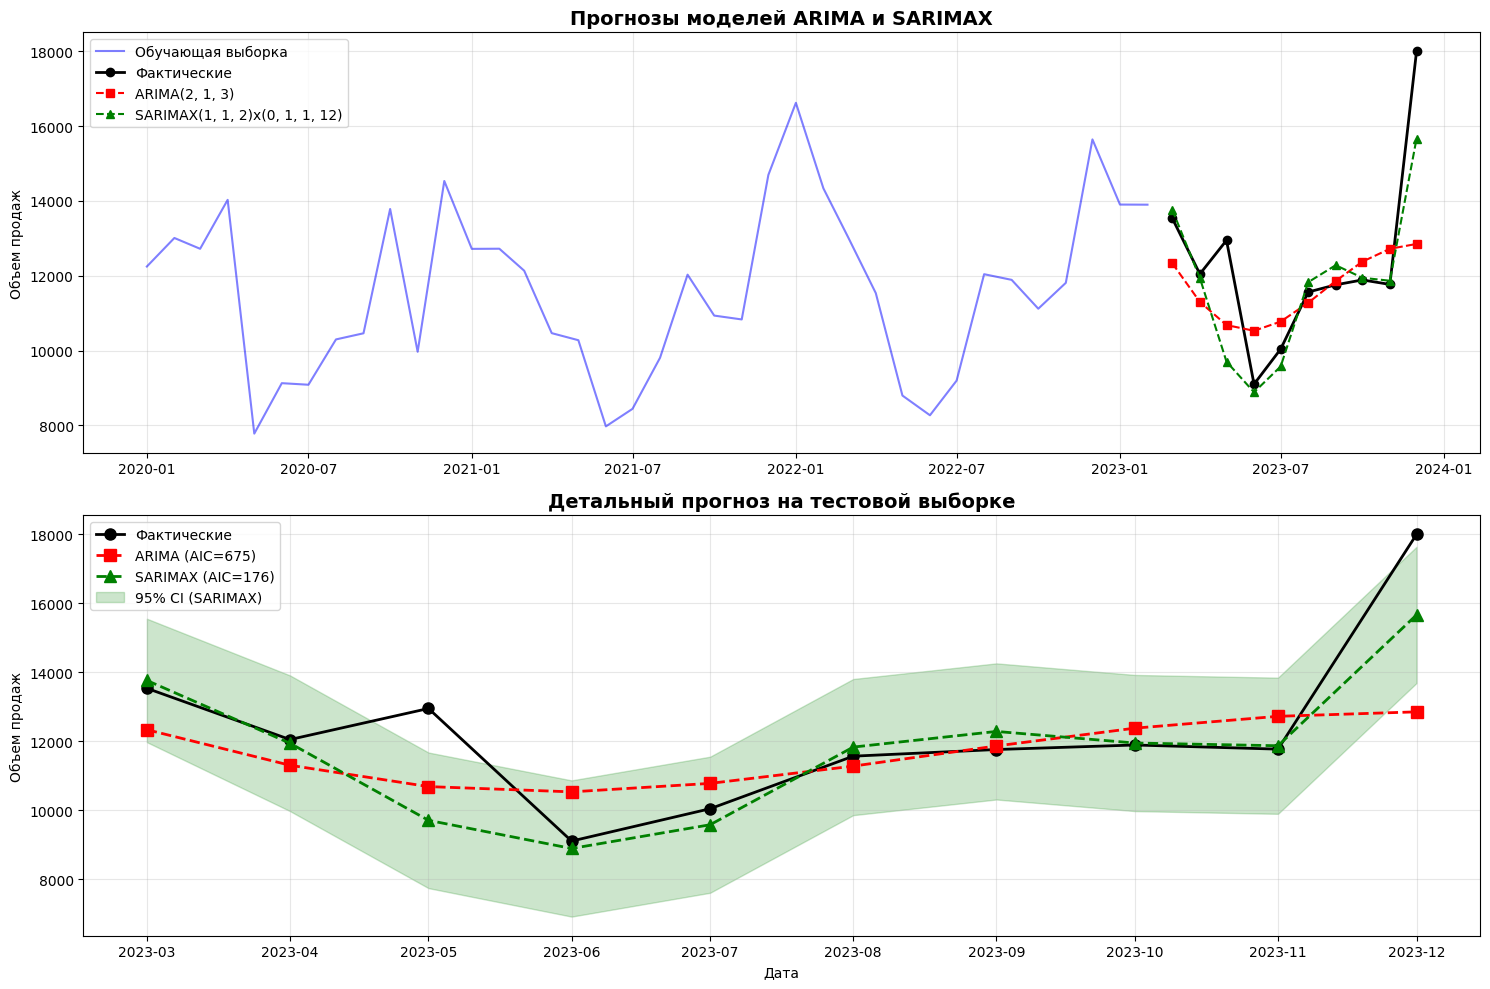


Фактические и прогнозные значения:
   Дата  Фактические   ARIMA  SARIMAX  Ошибка ARIMA  Ошибка SARIMAX
2023-03        13534 12334.0  13762.0        1200.0          -228.0
2023-04        12048 11302.0  11941.0         746.0           107.0
2023-05        12949 10684.0   9706.0        2265.0          3243.0
2023-06         9104 10531.0   8889.0       -1427.0           215.0
2023-07        10042 10777.0   9578.0        -735.0           464.0
2023-08        11566 11278.0  11830.0         288.0          -264.0
2023-09        11759 11862.0  12283.0        -103.0          -524.0
2023-10        11890 12378.0  11948.0        -488.0           -58.0
2023-11        11770 12722.0  11868.0        -952.0           -98.0
2023-12        17996 12851.0  15662.0        5145.0          2334.0


In [13]:
# Обучение финальных моделей
print("\nОбучение финальных моделей...")

# ARIMA
if best_arima is None:
    # Если не удалось подобрать, используем простую модель
    best_order = (1, 0, 1)
    arima_fitted = ARIMA(train['SalesAmount'], order=best_order).fit()
else:
    arima_fitted = best_arima

print(f"ARIMA{best_order} - AIC: {arima_fitted.aic:.2f}, BIC: {arima_fitted.bic:.2f}")

# SARIMAX
sarimax_fitted = best_sarimax
print(f"SARIMAX{best_order_s}x{best_seasonal} - AIC: {sarimax_fitted.aic:.2f}, BIC: {sarimax_fitted.bic:.2f}")

# %%
# Прогнозирование
forecast_steps = len(test)
arima_forecast = arima_fitted.forecast(steps=forecast_steps)
sarimax_forecast = sarimax_fitted.forecast(steps=forecast_steps)

# Создание DataFrame с прогнозами
forecast_df = pd.DataFrame({
    'Actual': test['SalesAmount'].values,
    'ARIMA': arima_forecast.values,
    'SARIMAX': sarimax_forecast.values
}, index=test.index)

# Визуализация прогнозов
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Полный ряд
axes[0].plot(train.index, train['SalesAmount'], label='Обучающая выборка', color='blue', alpha=0.5, linewidth=1.5)
axes[0].plot(test.index, test['SalesAmount'], label='Фактические', color='black', linewidth=2, marker='o', markersize=6)
axes[0].plot(test.index, arima_forecast, label=f'ARIMA{best_order}', color='red', linestyle='--', marker='s', markersize=6)
axes[0].plot(test.index, sarimax_forecast, label=f'SARIMAX{best_order_s}x{best_seasonal}', color='green', linestyle='--', marker='^', markersize=6)
axes[0].set_title('Прогнозы моделей ARIMA и SARIMAX', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Объем продаж')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Детальный прогноз
axes[1].plot(test.index, test['SalesAmount'], 'ko-', linewidth=2, markersize=8, label='Фактические')
axes[1].plot(test.index, arima_forecast, 'rs--', linewidth=2, markersize=8, 
             label=f'ARIMA (AIC={arima_fitted.aic:.0f})')
axes[1].plot(test.index, sarimax_forecast, 'g^--', linewidth=2, markersize=8, 
             label=f'SARIMAX (AIC={sarimax_fitted.aic:.0f})')
axes[1].set_title('Детальный прогноз на тестовой выборке', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Объем продаж')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

# Добавим доверительные интервалы для SARIMAX (если доступны)
try:
    sarimax_pred = sarimax_fitted.get_forecast(steps=forecast_steps)
    sarimax_ci = sarimax_pred.conf_int()
    axes[1].fill_between(test.index, 
                         sarimax_ci.iloc[:, 0], 
                         sarimax_ci.iloc[:, 1], 
                         color='green', alpha=0.2, label='95% CI (SARIMAX)')
    axes[1].legend(loc='best')
except:
    pass

plt.tight_layout()
plt.show()

# Выведем фактические и прогнозные значения
print("\nФактические и прогнозные значения:")
comparison = pd.DataFrame({
    'Дата': test.index.strftime('%Y-%m'),
    'Фактические': test['SalesAmount'].values,
    'ARIMA': arima_forecast.values.round(0),
    'SARIMAX': sarimax_forecast.values.round(0),
    'Ошибка ARIMA': (test['SalesAmount'].values - arima_forecast.values).round(0),
    'Ошибка SARIMAX': (test['SalesAmount'].values - sarimax_forecast.values).round(0)
})
print(comparison.to_string(index=False))

# 3. Финальная оценка моделей

In [16]:
# Расчет метрик
mse_arima = mean_squared_error(forecast_df['Actual'], forecast_df['ARIMA'])
mse_sarimax = mean_squared_error(forecast_df['Actual'], forecast_df['SARIMAX'])

r2_arima = r2_score(forecast_df['Actual'], forecast_df['ARIMA'])
r2_sarimax = r2_score(forecast_df['Actual'], forecast_df['SARIMAX'])

# Результаты в таблице
print("="*60)
print("МЕТРИКИ КАЧЕСТВА ПРОГНОЗА")
print("="*60)
print(f"{'Модель':<12} {'MSE':>12} {'RMSE':>12} {'R²':>12}")
print("-"*48)
print(f"{'ARIMA':<12} {mse_arima:>12.0f} {np.sqrt(mse_arima):>12.0f} {r2_arima:>12.3f}")
print(f"{'SARIMAX':<12} {mse_sarimax:>12.0f} {np.sqrt(mse_sarimax):>12.0f} {r2_sarimax:>12.3f}")
print("="*60)



МЕТРИКИ КАЧЕСТВА ПРОГНОЗА
Модель                MSE         RMSE           R²
------------------------------------------------
ARIMA             3740978         1934        0.267
SARIMAX           1665089         1290        0.674


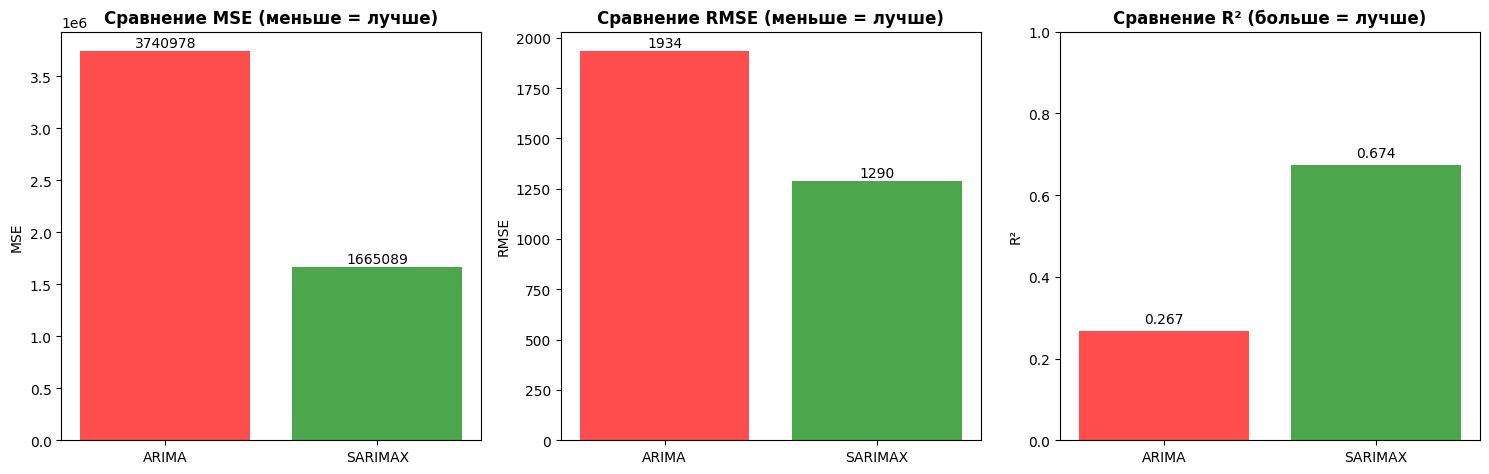

✓ Лучшая модель по MSE: SARIMAX
✓ Лучшая модель по R²: SARIMAX

ИНФОРМАЦИОННЫЕ КРИТЕРИИ
Модель                AIC          BIC
------------------------------------
ARIMA                 675          685
SARIMAX               176          177


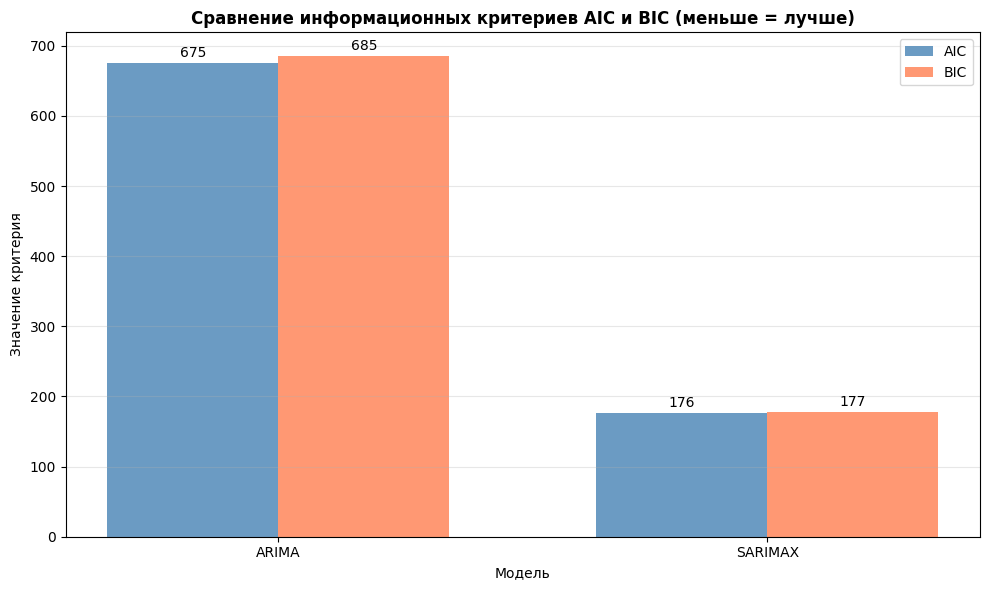

✓ Лучшая модель по AIC: SARIMAX
✓ Лучшая модель по BIC: SARIMAX


In [17]:
# Сравнение метрик
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MSE
models = ['ARIMA', 'SARIMAX']
mse_values = [mse_arima, mse_sarimax]
colors = ['red', 'green']
bars1 = axes[0].bar(models, mse_values, color=colors, alpha=0.7)
axes[0].set_title('Сравнение MSE (меньше = лучше)', fontweight='bold')
axes[0].set_ylabel('MSE')
for bar, val in zip(bars1, mse_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mse_values)*0.01,
                f'{val:.0f}', ha='center', fontsize=10)

# RMSE
rmse_values = [np.sqrt(mse_arima), np.sqrt(mse_sarimax)]
bars2 = axes[1].bar(models, rmse_values, color=colors, alpha=0.7)
axes[1].set_title('Сравнение RMSE (меньше = лучше)', fontweight='bold')
axes[1].set_ylabel('RMSE')
for bar, val in zip(bars2, rmse_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_values)*0.01,
                f'{val:.0f}', ha='center', fontsize=10)

# R²
r2_values = [r2_arima, r2_sarimax]
bars3 = axes[2].bar(models, r2_values, color=colors, alpha=0.7)
axes[2].set_title('Сравнение R² (больше = лучше)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
for bar, val in zip(bars3, r2_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Вывод
better_mse = "SARIMAX" if mse_sarimax < mse_arima else "ARIMA"
better_r2 = "SARIMAX" if r2_sarimax > r2_arima else "ARIMA"
print(f"✓ Лучшая модель по MSE: {better_mse}")
print(f"✓ Лучшая модель по R²: {better_r2}")

# Информационные критерии

print("\n" + "="*60)
print("ИНФОРМАЦИОННЫЕ КРИТЕРИИ")
print("="*60)
print(f"{'Модель':<12} {'AIC':>12} {'BIC':>12}")
print("-"*36)
print(f"{'ARIMA':<12} {arima_fitted.aic:>12.0f} {arima_fitted.bic:>12.0f}")
print(f"{'SARIMAX':<12} {sarimax_fitted.aic:>12.0f} {sarimax_fitted.bic:>12.0f}")
print("="*60)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

aic_values = [arima_fitted.aic, sarimax_fitted.aic]
bic_values = [arima_fitted.bic, sarimax_fitted.bic]

bars1 = ax.bar(x - width/2, aic_values, width, label='AIC', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, bic_values, width, label='BIC', color='coral', alpha=0.8)

ax.set_xlabel('Модель')
ax.set_ylabel('Значение критерия')
ax.set_title('Сравнение информационных критериев AIC и BIC (меньше = лучше)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{height:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

better_aic = "SARIMAX" if sarimax_fitted.aic < arima_fitted.aic else "ARIMA"
better_bic = "SARIMAX" if sarimax_fitted.bic < arima_fitted.bic else "ARIMA"
print(f"✓ Лучшая модель по AIC: {better_aic}")
print(f"✓ Лучшая модель по BIC: {better_bic}")

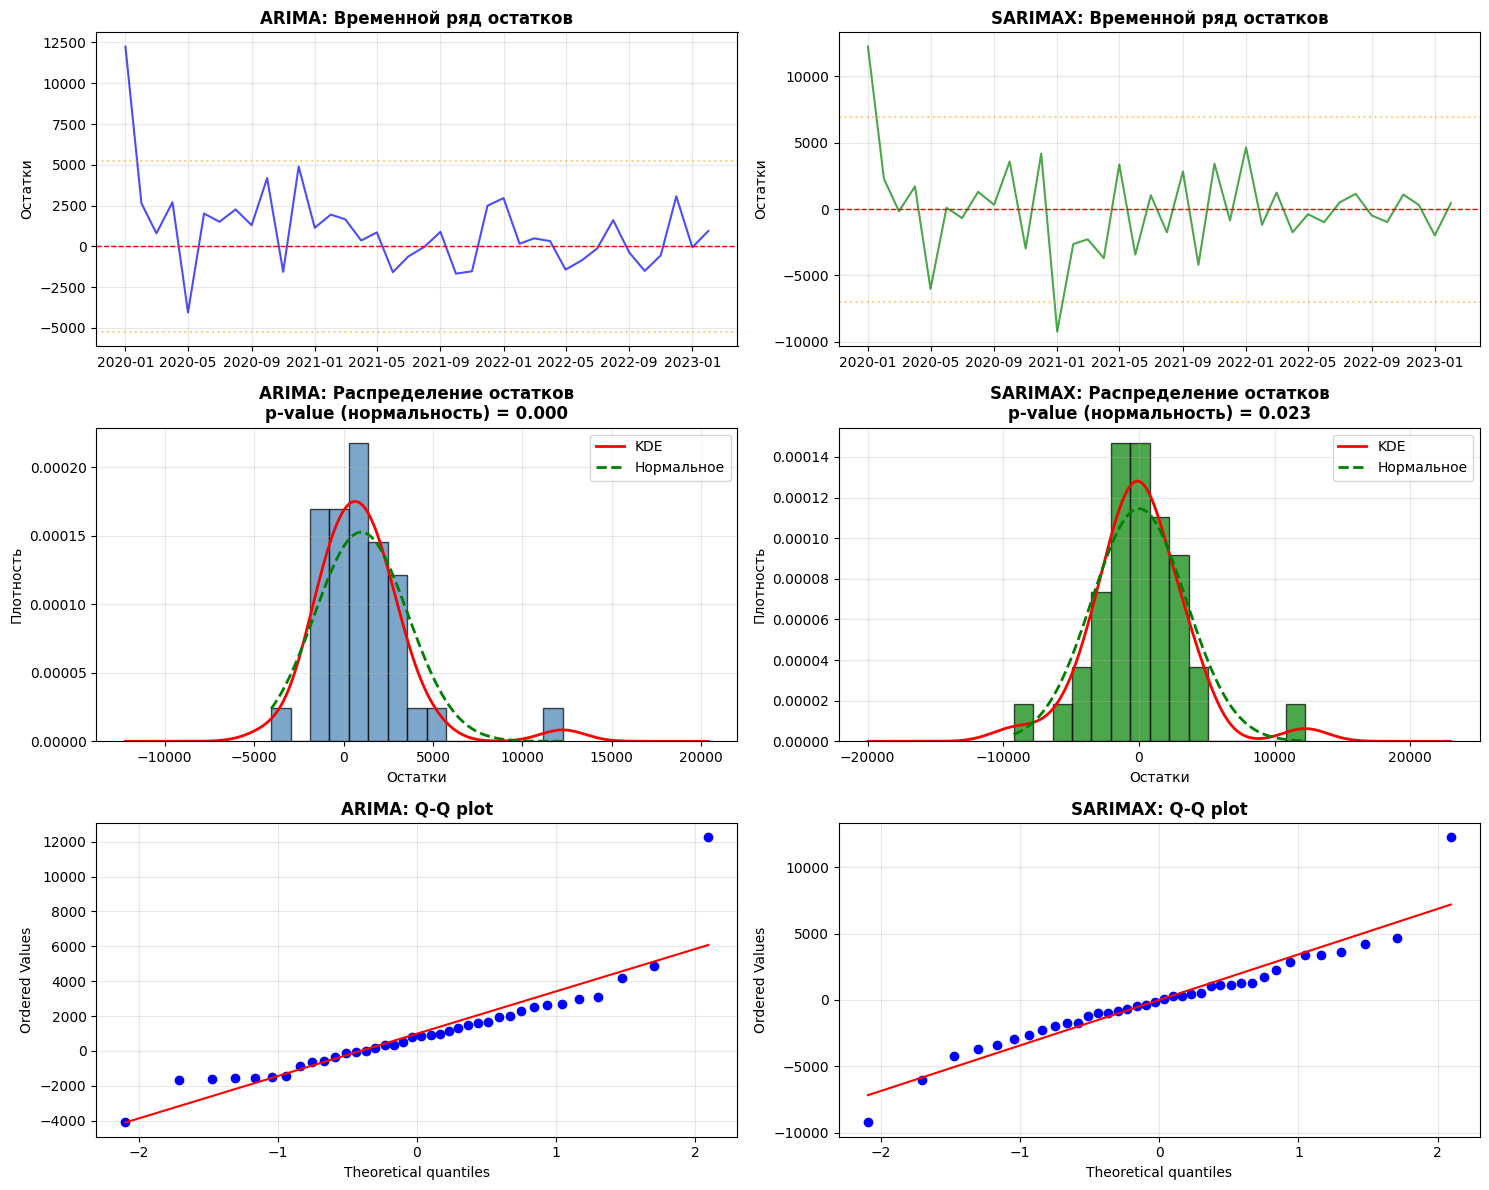

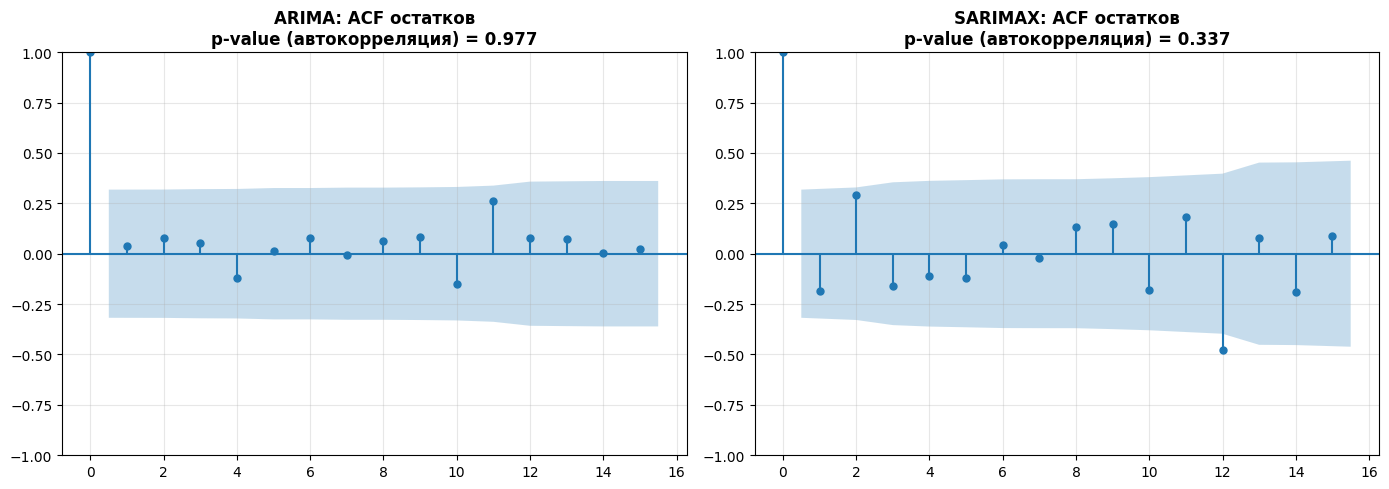

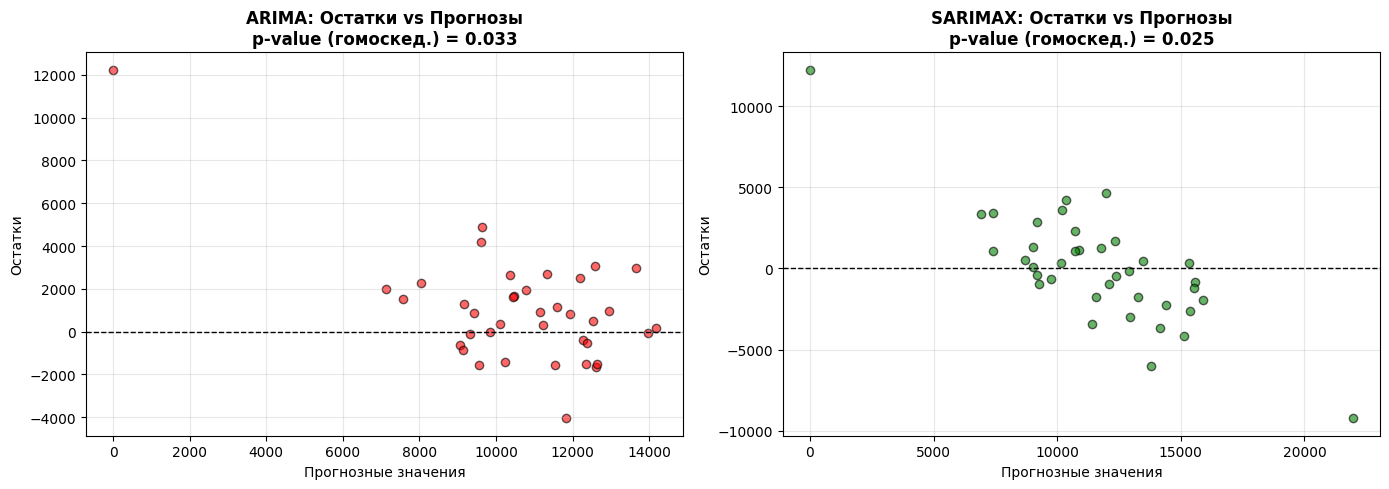


АНАЛИЗ ОСТАТКОВ МОДЕЛЕЙ
Модель       Нормальность              Автокорреляция            Гомоскедастичность  
----------------------------------------------------------------------------------
ARIMA        Нет (p=0.000)             Нет (p=0.977)             Нет (p=0.033)       
SARIMAX      Нет (p=0.023)             Нет (p=0.337)             Нет (p=0.025)       


In [18]:
# Анализ остатков
def check_residuals(residuals, model_name):
    """Компактный анализ остатков"""
    residuals = residuals.dropna()
    
    # 1. Нормальность (тест Шапиро-Уилка)
    _, p_norm = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
    normality = "Да" if p_norm > 0.05 else "Нет"
    
    # 2. Автокорреляция (тест Льюнга-Бокса)
    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    p_autocorr = lb_test['lb_pvalue'].values[0]
    autocorr = "Нет" if p_autocorr > 0.05 else "Есть"
    
    # 3. Гомоскедастичность (тест Бреуша-Пагана)
    X = sm.add_constant(np.arange(len(residuals)))
    _, p_hetero, _, _ = het_breuschpagan(residuals, X)
    heteroscedasticity = "Да" if p_hetero > 0.05 else "Нет"
    
    return {
        'Модель': model_name,
        'Нормальность': f"{normality} (p={p_norm:.3f})",
        'Автокорреляция': f"{autocorr} (p={p_autocorr:.3f})",
        'Гомоскедастичность': f"{heteroscedasticity} (p={p_hetero:.3f})",
        'p_norm': p_norm,
        'p_autocorr': p_autocorr,
        'p_hetero': p_hetero
    }

# Анализ остатков обеих моделей
arima_resid_check = check_residuals(arima_fitted.resid, 'ARIMA')
sarimax_resid_check = check_residuals(sarimax_fitted.resid, 'SARIMAX')

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# ARIMA остатки
# Временной ряд остатков
axes[0, 0].plot(arima_fitted.resid.index, arima_fitted.resid.values, 'b-', alpha=0.7)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[0, 0].axhline(y=2*arima_fitted.resid.std(), color='orange', linestyle=':', alpha=0.5)
axes[0, 0].axhline(y=-2*arima_fitted.resid.std(), color='orange', linestyle=':', alpha=0.5)
axes[0, 0].set_title(f'ARIMA: Временной ряд остатков', fontweight='bold')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].grid(True, alpha=0.3)

# Гистограмма остатков
axes[1, 0].hist(arima_fitted.resid, bins=15, density=True, alpha=0.7, color='steelblue', edgecolor='black')
# KDE
arima_fitted.resid.plot(kind='kde', ax=axes[1, 0], color='red', linewidth=2, label='KDE')

x = np.linspace(arima_fitted.resid.min(), arima_fitted.resid.max(), 100)
axes[1, 0].plot(x, stats.norm.pdf(x, arima_fitted.resid.mean(), arima_fitted.resid.std()), 
                'g--', linewidth=2, label='Нормальное')
axes[1, 0].set_title(f'ARIMA: Распределение остатков\np-value (нормальность) = {arima_resid_check["p_norm"]:.3f}', 
                     fontweight='bold')
axes[1, 0].set_xlabel('Остатки')
axes[1, 0].set_ylabel('Плотность')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(arima_fitted.resid, dist="norm", plot=axes[2, 0])
axes[2, 0].set_title(f'ARIMA: Q-Q plot', fontweight='bold')
axes[2, 0].grid(True, alpha=0.3)

# SARIMAX остатки
# Временной ряд остатков
axes[0, 1].plot(sarimax_fitted.resid.index, sarimax_fitted.resid.values, 'g-', alpha=0.7)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[0, 1].axhline(y=2*sarimax_fitted.resid.std(), color='orange', linestyle=':', alpha=0.5)
axes[0, 1].axhline(y=-2*sarimax_fitted.resid.std(), color='orange', linestyle=':', alpha=0.5)
axes[0, 1].set_title(f'SARIMAX: Временной ряд остатков', fontweight='bold')
axes[0, 1].set_ylabel('Остатки')
axes[0, 1].grid(True, alpha=0.3)

# Гистограмма остатков
axes[1, 1].hist(sarimax_fitted.resid, bins=15, density=True, alpha=0.7, color='green', edgecolor='black')
# KDE
sarimax_fitted.resid.plot(kind='kde', ax=axes[1, 1], color='red', linewidth=2, label='KDE')

x = np.linspace(sarimax_fitted.resid.min(), sarimax_fitted.resid.max(), 100)
axes[1, 1].plot(x, stats.norm.pdf(x, sarimax_fitted.resid.mean(), sarimax_fitted.resid.std()), 
                'g--', linewidth=2, label='Нормальное')
axes[1, 1].set_title(f'SARIMAX: Распределение остатков\np-value (нормальность) = {sarimax_resid_check["p_norm"]:.3f}', 
                     fontweight='bold')
axes[1, 1].set_xlabel('Остатки')
axes[1, 1].set_ylabel('Плотность')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(sarimax_fitted.resid, dist="norm", plot=axes[2, 1])
axes[2, 1].set_title(f'SARIMAX: Q-Q plot', fontweight='bold')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ACF остатков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(arima_fitted.resid, lags=15, ax=axes[0])
axes[0].set_title(f'ARIMA: ACF остатков\np-value (автокорреляция) = {arima_resid_check["p_autocorr"]:.3f}', 
                  fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_acf(sarimax_fitted.resid, lags=15, ax=axes[1])
axes[1].set_title(f'SARIMAX: ACF остатков\np-value (автокорреляция) = {sarimax_resid_check["p_autocorr"]:.3f}', 
                  fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Остатки vs Прогнозы (гомоскедастичность)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ARIMA
axes[0].scatter(arima_fitted.fittedvalues, arima_fitted.resid, alpha=0.6, color='red', edgecolors='black')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Прогнозные значения')
axes[0].set_ylabel('Остатки')
axes[0].set_title(f'ARIMA: Остатки vs Прогнозы\np-value (гомоскед.) = {arima_resid_check["p_hetero"]:.3f}', 
                  fontweight='bold')
axes[0].grid(True, alpha=0.3)

# SARIMAX
axes[1].scatter(sarimax_fitted.fittedvalues, sarimax_fitted.resid, alpha=0.6, color='green', edgecolors='black')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Прогнозные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title(f'SARIMAX: Остатки vs Прогнозы\np-value (гомоскед.) = {sarimax_resid_check["p_hetero"]:.3f}', 
                  fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Таблица с результатами анализа остатков
print("\n" + "="*70)
print("АНАЛИЗ ОСТАТКОВ МОДЕЛЕЙ")
print("="*70)
print(f"{'Модель':<12} {'Нормальность':<25} {'Автокорреляция':<25} {'Гомоскедастичность':<20}")
print("-"*82)
print(f"{arima_resid_check['Модель']:<12} {arima_resid_check['Нормальность']:<25} "
      f"{arima_resid_check['Автокорреляция']:<25} {arima_resid_check['Гомоскедастичность']:<20}")
print(f"{sarimax_resid_check['Модель']:<12} {sarimax_resid_check['Нормальность']:<25} "
      f"{sarimax_resid_check['Автокорреляция']:<25} {sarimax_resid_check['Гомоскедастичность']:<20}")
print("="*82)

1. Сравнение точности прогнозов
Модель SARIMAX показала значительно лучше результаты по всем метрикам:

Модель SARIMAX объясняет 67.4% дисперсии данных (R²=0.674), что более чем в 2.5 раза лучше ARIMA (26.7%)

Средняя ошибка прогноза SARIMAX составляет 1290 против 1934 у ARIMA

SARIMAX точнее прогнозирует как уровни продаж, так и их динамику

1. Информационные критерии
SARIMAX имеет существенно лучшие информационные критерии:

Критерий	ARIMA	SARIMAX	Разница
AIC	675 vs 176 в 3.84 раза
BIC	685 vs 177 в 3.86 раза
Интерпретация:

Более низкие значения AIC и BIC у SARIMAX указывают на лучшее соотношение качества и сложности модели

Разница в ~500 пунктов является статистически значимой (обычно разница >10 уже существенна)

SARIMAX лучше описывает данные при меньшем количестве эффективных параметров

3. Анализ остатков
Обе модели имеют проблемы с качеством остатков:

Нормальность: Остатки обеих моделей не подчиняются нормальному распределению (p<0.05), что может указывать на наличие неучтенных факторов

Автокорреляция: Отсутствует в обеих моделях (p>0.05) - модели правильно учли временную структуру данных

Гомоскедастичность: Присутствует гетероскедастичность (p<0.05) - дисперсия остатков непостоянна во времени